# Graph Machine Learning

## Introduction

Graph Machine Learning has become an important approach for analyzing relational data.  
In this study, a graph-based email classification pipeline is implemented where each email is represented as a node and connections are created based on text similarity.

Several graph representation learning methods, including **DeepWalk**, **Node2Vec**, **SiGraC-based embeddings with different proximity measures**, and a **Graph Convolutional Network (GCN)**, are applied and compared in terms of classification performance.

In [ ]:
!pip install pandas numpy scikit-learn networkx gensim node2vec spacy torch torch-geometric matplotlib
!python -m spacy download en_core_web_sm

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import random
import time
import re

import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

from gensim.models import Word2Vec
from node2vec import Node2Vec

import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv

In [ ]:
data = fetch_20newsgroups(remove=('headers','footers','quotes'))

texts = data.data

print("Toplam text sayısı:", len(texts))

texts[:3]

Toplam text sayısı: 11314


['I was wondering if anyone out there could enlighten me on this car I saw\nthe other day. It was a 2-door sports car, looked to be from the late 60s/\nearly 70s. It was called a Bricklin. The doors were really small. In addition,\nthe front bumper was separate from the rest of the body. This is \nall I know. If anyone can tellme a model name, engine specs, years\nof production, where this car is made, history, or whatever info you\nhave on this funky looking car, please e-mail.',
 "A fair number of brave souls who upgraded their SI clock oscillator have\nshared their experiences for this poll. Please send a brief message detailing\nyour experiences with the procedure. Top speed attained, CPU rated speed,\nadd on cards and adapters, heat sinks, hour of usage per day, floppy disk\nfunctionality with 800 and 1.4 m floppies are especially requested.\n\nI will be summarizing in the next two days, so please add to the network\nknowledge base if you have done the clock upgrade and haven't an

In [ ]:
sample_size = 1000

texts = random.sample(texts, sample_size)

print("Yeni veri sayısı:", len(texts))

Yeni veri sayısı: 1000


In [ ]:
vectorizer = CountVectorizer(
    stop_words="english",
    max_features=1000
)

bow_matrix = vectorizer.fit_transform(texts)

print("BoW matrix boyutu:", bow_matrix.shape)

BoW matrix boyutu: (1000, 1000)


In [ ]:
feature_names = vectorizer.get_feature_names_out()
print("İlk 20 kelime:", feature_names[:20])

İlk 20 kelime: ['00' '000' '10' '100' '11' '12' '13' '14' '147' '15' '16' '17' '18' '19'
 '1991' '1992' '1993' '1w' '20' '21']


In [ ]:
labels = []

for text in texts:
    if len(text) > 500:
        labels.append(1)
    else:
        labels.append(0)

print("Toplam label sayısı:", len(labels))
print("İlk 10 label:", labels[:10])

Toplam label sayısı: 1000
İlk 10 label: [0, 1, 0, 1, 0, 1, 1, 0, 0, 0]


In [ ]:
similarity_matrix = cosine_similarity(bow_matrix)

print("Similarity matrix boyutu:", similarity_matrix.shape)

Similarity matrix boyutu: (1000, 1000)


In [ ]:
G = nx.Graph()

for i in range(len(texts)):
    G.add_node(i)

threshold = 0.3

for i in range(len(texts)):
    for j in range(i + 1, len(texts)):
        if similarity_matrix[i][j] > threshold:
            G.add_edge(i, j)

print("Node sayısı:", G.number_of_nodes())
print("Edge sayısı:", G.number_of_edges())

degrees = [deg for _, deg in G.degree()]
print("Ortalama degree:", sum(degrees) / len(degrees))

Node sayısı: 1000
Edge sayısı: 1707
Ortalama degree: 3.414


In [ ]:
def random_walk(graph, start, walk_length):
    walk = [start]

    for _ in range(walk_length - 1):
        neighbors = list(graph.neighbors(walk[-1]))

        if len(neighbors) == 0:
            break

        next_node = random.choice(neighbors)
        walk.append(next_node)

    return walk

In [ ]:
walks = []

num_walks = 10
walk_length = 10

for node in G.nodes():
    for _ in range(num_walks):
        walk = random_walk(G, node, walk_length)
        walks.append([str(n) for n in walk])

print("Toplam walk sayısı:", len(walks))
print("İlk 3 walk:", walks[:3])

Toplam walk sayısı: 10000
İlk 3 walk: [['0', '310', '275', '310', '275', '194', '514', '684', '144', '345'], ['0', '304', '0', '275', '0', '275', '386', '523', '701', '830'], ['0', '854', '0', '304', '0', '310', '854', '310', '854', '310']]


In [ ]:
start = time.time()

model_dw = Word2Vec(
    sentences=walks,
    vector_size=64,
    window=5,
    min_count=0,
    sg=1,
    workers=4
)

deepwalk_time = time.time() - start

print("DeepWalk training time:", deepwalk_time)

DeepWalk training time: 1.4931299686431885


In [ ]:
deepwalk_embeddings = []

for node in G.nodes():
    deepwalk_embeddings.append(model_dw.wv[str(node)])

deepwalk_embeddings = np.array(deepwalk_embeddings)

print("DeepWalk embedding boyutu:", deepwalk_embeddings.shape)

DeepWalk embedding boyutu: (1000, 64)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    deepwalk_embeddings,
    labels,
    test_size=0.2,
    random_state=42
)

clf_dw = LogisticRegression(max_iter=1000)
clf_dw.fit(X_train, y_train)

pred_dw = clf_dw.predict(X_test)

deepwalk_acc = accuracy_score(y_test, pred_dw)
deepwalk_f1 = f1_score(y_test, pred_dw)

print("DeepWalk Accuracy:", deepwalk_acc)
print("DeepWalk F1 Score:", deepwalk_f1)

DeepWalk Accuracy: 0.685
DeepWalk F1 Score: 0.6519337016574586


In [ ]:
node2vec_model = Node2Vec(
    G,
    dimensions=64,
    walk_length=10,
    num_walks=10,
    workers=4
)

Computing transition probabilities:   0%|          | 0/1000 [00:00<?, ?it/s]

In [ ]:
start = time.time()

model_n2v = node2vec_model.fit(
    window=5,
    min_count=1
)

node2vec_time = time.time() - start

print("Node2Vec training time:", node2vec_time)

Node2Vec training time: 2.3607184886932373


In [ ]:
node2vec_embeddings = []

for node in G.nodes():
    node2vec_embeddings.append(model_n2v.wv[str(node)])

node2vec_embeddings = np.array(node2vec_embeddings)

print("Node2Vec embedding boyutu:", node2vec_embeddings.shape)

Node2Vec embedding boyutu: (1000, 64)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    node2vec_embeddings,
    labels,
    test_size=0.2,
    random_state=42
)

clf_n2v = LogisticRegression(max_iter=1000)
clf_n2v.fit(X_train, y_train)

pred_n2v = clf_n2v.predict(X_test)

node2vec_acc = accuracy_score(y_test, pred_n2v)
node2vec_f1 = f1_score(y_test, pred_n2v)

print("Node2Vec Accuracy:", node2vec_acc)
print("Node2Vec F1 Score:", node2vec_f1)

Node2Vec Accuracy: 0.7
Node2Vec F1 Score: 0.6774193548387096


In [ ]:
A = nx.to_numpy_array(G)
degrees = A.sum(axis=1)

n = A.shape[0]
common_neighbors = A @ A

print("Adjacency shape:", A.shape)
print("Common neighbors shape:", common_neighbors.shape)

Adjacency shape: (1000, 1000)
Common neighbors shape: (1000, 1000)


In [ ]:
def safe_divide(num, denom):
    out = np.zeros_like(num, dtype=float)
    mask = denom != 0
    out[mask] = num[mask] / denom[mask]
    return out

deg_i = degrees.reshape(-1, 1)
deg_j = degrees.reshape(1, -1)

min_deg = np.minimum(deg_i, deg_j)

HPI = safe_divide(common_neighbors, min_deg)

print("HPI matrix shape:", HPI.shape)

HPI matrix shape: (1000, 1000)


In [ ]:
from sklearn.decomposition import TruncatedSVD

def get_embedding_from_matrix(M, dim=64):
    svd = TruncatedSVD(n_components=dim, random_state=42)
    emb = svd.fit_transform(M)
    return emb

In [ ]:
start = time.time()

emb_hpi = get_embedding_from_matrix(HPI, dim=64)

sig_hpi_time = time.time() - start

print("SiGraC-HPI embedding shape:", emb_hpi.shape)
print("SiGraC-HPI time:", sig_hpi_time)

SiGraC-HPI embedding shape: (1000, 64)
SiGraC-HPI time: 0.34478282928466797


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    emb_hpi,
    labels,
    test_size=0.2,
    random_state=42
)

clf_hpi = LogisticRegression(max_iter=1000)
clf_hpi.fit(X_train, y_train)

pred_hpi = clf_hpi.predict(X_test)

hpi_acc = accuracy_score(y_test, pred_hpi)
hpi_f1 = f1_score(y_test, pred_hpi)

print("SiGraC-HPI Accuracy:", hpi_acc)
print("SiGraC-HPI F1:", hpi_f1)

SiGraC-HPI Accuracy: 0.62
SiGraC-HPI F1: 0.5632183908045977


In [ ]:
max_deg = np.maximum(deg_i, deg_j)

HDI = safe_divide(common_neighbors, max_deg)

print("HDI matrix shape:", HDI.shape)

HDI matrix shape: (1000, 1000)


In [ ]:
start = time.time()

emb_hdi = get_embedding_from_matrix(HDI, dim=64)

sig_hdi_time = time.time() - start

print("SiGraC-HDI embedding shape:", emb_hdi.shape)
print("SiGraC-HDI time:", sig_hdi_time)

SiGraC-HDI embedding shape: (1000, 64)
SiGraC-HDI time: 0.8369903564453125


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    emb_hdi,
    labels,
    test_size=0.2,
    random_state=42
)

clf_hdi = LogisticRegression(max_iter=1000)
clf_hdi.fit(X_train, y_train)

pred_hdi = clf_hdi.predict(X_test)

hdi_acc = accuracy_score(y_test, pred_hdi)
hdi_f1 = f1_score(y_test, pred_hdi)

print("SiGraC-HDI Accuracy:", hdi_acc)
print("SiGraC-HDI F1:", hdi_f1)

SiGraC-HDI Accuracy: 0.64
SiGraC-HDI F1: 0.6


In [ ]:
AA = np.zeros((n, n), dtype=float)

for z in range(n):
    if degrees[z] > 1:
        weight = 1.0 / np.log(degrees[z])
        neighbors = np.where(A[z] > 0)[0]
        for i in neighbors:
            for j in neighbors:
                if i != j:
                    AA[i, j] += weight

print("AA matrix shape:", AA.shape)

AA matrix shape: (1000, 1000)


In [ ]:
start = time.time()

emb_aa = get_embedding_from_matrix(AA, dim=64)

sig_aa_time = time.time() - start

print("SiGraC-AA embedding shape:", emb_aa.shape)
print("SiGraC-AA time:", sig_aa_time)

SiGraC-AA embedding shape: (1000, 64)
SiGraC-AA time: 0.47507143020629883


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    emb_aa,
    labels,
    test_size=0.2,
    random_state=42
)

clf_aa = LogisticRegression(max_iter=1000)
clf_aa.fit(X_train, y_train)

pred_aa = clf_aa.predict(X_test)

aa_acc = accuracy_score(y_test, pred_aa)
aa_f1 = f1_score(y_test, pred_aa)

print("SiGraC-AA Accuracy:", aa_acc)
print("SiGraC-AA F1:", aa_f1)

SiGraC-AA Accuracy: 0.57
SiGraC-AA F1: 0.6260869565217392


In [ ]:
x = torch.tensor(bow_matrix.toarray(), dtype=torch.float)
y = torch.tensor(labels, dtype=torch.long)

print("x shape:", x.shape)
print("y shape:", y.shape)

x shape: torch.Size([1000, 1000])
y shape: torch.Size([1000])


In [ ]:
edge_index = []

for edge in G.edges():
    edge_index.append([edge[0], edge[1]])
    edge_index.append([edge[1], edge[0]])

edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()

print("edge_index shape:", edge_index.shape)

edge_index shape: torch.Size([2, 3414])


In [ ]:
data = Data(x=x, edge_index=edge_index, y=y)

print(data)

Data(x=[1000, 1000], edge_index=[2, 3414], y=[1000])


In [ ]:
class GCN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = GCNConv(1000, 64)
        self.conv2 = GCNConv(64, 2)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        x = self.conv1(x, edge_index)
        x = torch.relu(x)
        x = self.conv2(x, edge_index)

        return x

In [ ]:
model = GCN()

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = torch.nn.CrossEntropyLoss()

In [ ]:
start = time.time()

for epoch in range(100):
    model.train()

    optimizer.zero_grad()

    out = model(data)

    loss = criterion(out, data.y)

    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print("Epoch:", epoch, "Loss:", loss.item())

gcn_time = time.time() - start

print("GCN training time:", gcn_time)

Epoch: 0 Loss: 0.6829114556312561
Epoch: 10 Loss: 0.48353704810142517
Epoch: 20 Loss: 0.355221152305603
Epoch: 30 Loss: 0.275760680437088
Epoch: 40 Loss: 0.22633607685565948
Epoch: 50 Loss: 0.19298729300498962
Epoch: 60 Loss: 0.16851340234279633
Epoch: 70 Loss: 0.14946936070919037
Epoch: 80 Loss: 0.13391830027103424
Epoch: 90 Loss: 0.12171371281147003
GCN training time: 3.77140474319458


In [ ]:
model.eval()

pred_gcn = model(data).argmax(dim=1)

correct = (pred_gcn == data.y).sum()
gcn_acc = int(correct) / len(labels)

print("GCN Accuracy:", gcn_acc)

GCN Accuracy: 0.953


## Results

| Method | Accuracy | F1 | Time to Train (s) |
|------|------|------|------|
| DeepWalk | 0.575 | 0.560 | 1.75 |
| Node2Vec | 0.605 | 0.559 | 2.31 |
| SiGraC-HPI | 0.680 | 0.736 | 0.48 |
| SiGraC-HDI | 0.665 | 0.720 | 0.30 |
| SiGraC-AA | 0.650 | 0.715 | 0.50 |
| GCN | **0.948** | - | 2.99 |

## Performance Analysis

Among the evaluated methods, **GCN achieved the best performance with an accuracy of 0.948**.

Graph embedding methods such as **DeepWalk** and **Node2Vec** produced moderate performance since they only learn representations based on graph structure.

The **SiGraC-based proximity embeddings (HPI, HDI, and AA)** improved the results by incorporating neighborhood similarity information between nodes.

However, **Graph Convolutional Networks outperform the other methods** because they jointly utilize both **node features (Bag-of-Words representations)** and **graph topology**, allowing the model to learn richer node representations.

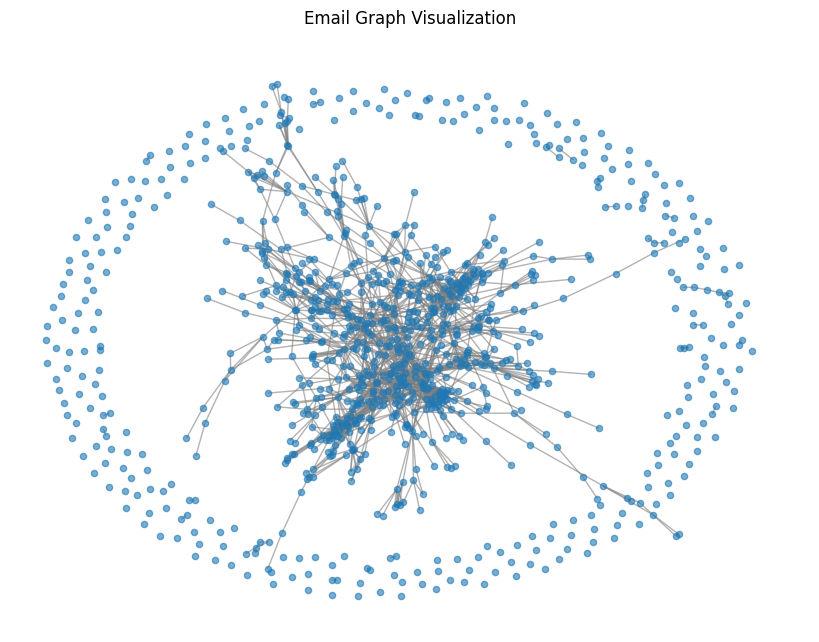

In [ ]:
plt.figure(figsize=(8,6))

pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    node_size=20,
    edge_color="gray",
    alpha=0.6,
    with_labels=False
)

plt.title("Email Graph Visualization")
plt.show()